# **ORIGINAL TIMESNET MODEL [FROM GITHUB BY AUTHOR] + BI LSTM HYBRID MODEL**

https://github.com/thuml/Time-Series-Library.git

In [ ]:
!pip install torch torchvision torchaudio numpy pandas scikit-learn matplotlib


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt


In [ ]:
# Load training and testing datasets (replace "Training.csv" and "Testing.csv" with your actual paths)
train_data = pd.read_csv("Training.csv")
test_data = pd.read_csv("Testing.csv")

# Convert relevant columns to numeric
for col in ["Close", "Open", "High", "Low"]:
    train_data[col] = pd.to_numeric(train_data[col], errors="coerce")
    test_data[col] = pd.to_numeric(test_data[col], errors="coerce")

# Drop NaN values
train_data = train_data.dropna(subset=["Close", "Open", "High", "Low"])
test_data = test_data.dropna(subset=["Close", "Open", "High", "Low"])

# Features (X) and Target (y)
X_train_full = train_data[["Open", "High", "Low"]].values
y_train_full = train_data["Close"].values
X_test = test_data[["Open", "High", "Low"]].values
y_test = test_data["Close"].values

# Train-Validation Split
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)

# Convert to PyTorch tensors
X_train = torch.tensor(X_train).float().unsqueeze(1)  # (batch_size, seq_len, features)
X_val = torch.tensor(X_val).float().unsqueeze(1)
X_test = torch.tensor(X_test).float().unsqueeze(1)
y_train = torch.tensor(y_train).float()
y_val = torch.tensor(y_val).float()
y_test = torch.tensor(y_test).float()

# Placeholder time marks (if no additional time-related features are provided)
x_mark_train = torch.zeros_like(X_train)
x_mark_val = torch.zeros_like(X_val)
x_mark_test = torch.zeros_like(X_test)



In [ ]:
def FFT_for_Period(x, k=2):
    xf = torch.fft.rfft(x, dim=1)
    frequency_list = abs(xf).mean(0).mean(-1)
    frequency_list[0] = 0  # Ignore zero-frequency component
    k = min(k, len(frequency_list))  # Ensure k doesn't exceed available frequencies
    _, top_list = torch.topk(frequency_list, k)
    top_list = top_list.detach().cpu().numpy()
    period = x.shape[1] // top_list
    return period, abs(xf).mean(-1)[:, top_list]


In [ ]:
class TimesBlock(nn.Module):
    def __init__(self, configs):
        super(TimesBlock, self).__init__()
        self.seq_len = configs.seq_len
        self.pred_len = configs.pred_len
        self.k = configs.top_k
        self.conv = nn.Sequential(
            nn.Conv2d(1, configs.d_model, kernel_size=(3, 3), padding=(1, 1)),
            nn.GELU(),
            nn.Conv2d(configs.d_model, 1, kernel_size=(3, 3), padding=(1, 1))
        )

    def forward(self, x):
        B, T, N = x.size()
        period_list, period_weight = FFT_for_Period(x, self.k)

        res = []
        for i in range(self.k):
            period = period_list[i]
            if period == 0:  # Avoid divide-by-zero errors
                continue
            length = ((self.seq_len + self.pred_len) // period + 1) * period
            padding = torch.zeros([B, length - (self.seq_len + self.pred_len), N]).to(x.device)
            out = torch.cat([x, padding], dim=1)
            out = out.reshape(B, length // period, period, N).permute(0, 3, 1, 2).contiguous()
            out = self.conv(out)
            out = out.permute(0, 2, 3, 1).reshape(B, -1, N)
            res.append(out[:, :(self.seq_len + self.pred_len), :])
        res = torch.stack(res, dim=-1).mean(-1)  # Aggregate across k
        return res + x  # Residual connection

class Model(nn.Module):
    def __init__(self, configs):
        super(Model, self).__init__()
        self.seq_len = configs.seq_len
        self.pred_len = configs.pred_len
        self.blocks = nn.ModuleList([TimesBlock(configs) for _ in range(configs.e_layers)])
        self.linear = nn.Linear(configs.seq_len, configs.pred_len)

    def forward(self, x, x_mark, *args):
        for block in self.blocks:
            x = block(x)
        x = x.permute(0, 2, 1)  # Adjust for linear layer
        x = self.linear(x)
        return x.permute(0, 2, 1)


In [ ]:
class HybridModel(nn.Module):
    def __init__(self, timesnet_config, input_dim, hidden_dim, output_dim, num_lstm_layers):
        super(HybridModel, self).__init__()
        self.timesnet = Model(timesnet_config)
        self.bi_lstm = nn.LSTM(input_size=input_dim, hidden_size=hidden_dim,
                               num_layers=num_lstm_layers, batch_first=True, bidirectional=True)
        self.dense = nn.Linear(hidden_dim * 2, output_dim)  # Bidirectional

    def forward(self, x, x_mark):
        timesnet_out = self.timesnet(x, x_mark, None, None)
        lstm_out, _ = self.bi_lstm(timesnet_out)
        predictions = self.dense(lstm_out[:, -1, :])  # Use last time step
        return predictions


In [ ]:
# TimesNet configuration
class Configs:
    def __init__(self, config_dict):
        for key, value in config_dict.items():
            setattr(self, key, value)

timesnet_config = Configs({
    "seq_len": 30, "pred_len": 10, "d_model": 64, "top_k": 3,
    "num_kernels": 3, "e_layers": 2, "d_ff": 128, "enc_in": 3,
    "c_out": 1, "embed": "fixed", "freq": "h", "dropout": 0.1,
    "task_name": "long_term_forecast"
})

# Instantiate model
model = HybridModel(timesnet_config, input_dim=64, hidden_dim=128, output_dim=1, num_lstm_layers=2)

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training loop
epochs = 10
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    predictions = model(X_train, x_mark_train)
    loss = criterion(predictions.squeeze(), y_train)
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch + 1}, Loss: {loss.item()}")


<ipython-input-39-1e168749ab64>:8: RuntimeWarning: divide by zero encountered in floor_divide
  period = x.shape[1] // top_list


IndexError: index 1 is out of bounds for axis 0 with size 1

# **HYBRID MODEL**

**Step 1: Install Dependencies and Clone the Repository**

Since TimesNet is part of the Time-Series-Library, you'll need to clone the repository and set it up.

In [ ]:
# Install necessary dependencies
!pip install torch einops

# Clone the Time-Series-Library repository
!git clone https://github.com/thuml/Time-Series-Library.git
%cd Time-Series-Library


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 80.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 59.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 53.0 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [ ]:
!ls
!ls models


CONTRIBUTING.md  exp	 LICENSE  pic	     requirements.txt  scripts	 utils
data_provider	 layers  models   README.md  run.py	       tutorial
Autoformer.py	__init__.py	     Nonstationary_Transformer.py  TemporalFusionTransformer.py
Crossformer.py	iTransformer.py      PatchTST.py		   TiDE.py
DLinear.py	Koopa.py	     PAttn.py			   TimeMixer.py
ETSformer.py	LightTS.py	     __pycache__		   TimesNet.py
FEDformer.py	Mamba.py	     Pyraformer.py		   TimeXer.py
FiLM.py		MambaSimple.py	     Reformer.py		   Transformer.py
FreTS.py	MICN.py		     SCINet.py			   TSMixer.py
Informer.py	MultiPatchFormer.py  SegRNN.py			   WPMixer.py


In [ ]:
import sys
sys.path.append('/content/Time-Series-Library/models')


In [ ]:
!pwd  # Check current working directory
!ls /content  # Confirm repo folder location
!ls /content/Time-Series-Library  # Confirm TimesNet.py presence


/content/Time-Series-Library
sample_data  Time-Series-Library
CONTRIBUTING.md  exp	 LICENSE  pic	     requirements.txt  scripts	 utils
data_provider	 layers  models   README.md  run.py	       tutorial


In [ ]:
!grep -r "class TimesBlock" /content/Time-Series-Library


/content/Time-Series-Library/models/TimesNet.py:class TimesBlock(nn.Module):
/content/Time-Series-Library/tutorial/TimesNet_tutorial.ipynb:    "class TimesBlock(nn.Module):\n",


In [ ]:
!grep -A 10 "class TimesBlock" /content/Time-Series-Library/models/TimesNet.py


class TimesBlock(nn.Module):
    def __init__(self, configs):
        super(TimesBlock, self).__init__()
        self.seq_len = configs.seq_len
        self.pred_len = configs.pred_len
        self.k = configs.top_k
        # parameter-efficient design
        self.conv = nn.Sequential(
            Inception_Block_V1(configs.d_model, configs.d_ff,
                               num_kernels=configs.num_kernels),
            nn.GELU(),


**Step 2: Import Libraries**

We'll import essential libraries for data handling, model building, and evaluation.

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, mean_absolute_percentage_error,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from TimesNet import TimesBlock
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout


**Step 3: Data Preprocessing**

We'll follow the same preprocessing logic.

In [ ]:
# Load the data
train_data = pd.read_csv("Training.csv")
test_data = pd.read_csv("Testing.csv")

# Convert relevant columns to numeric
for col in ["Close", "Open", "High", "Low"]:
    train_data[col] = pd.to_numeric(train_data[col], errors="coerce")
    test_data[col] = pd.to_numeric(test_data[col], errors="coerce")

# Drop NaN values
train_data.dropna(subset=["Close", "Open", "High", "Low"], inplace=True)
test_data.dropna(subset=["Close", "Open", "High", "Low"], inplace=True)

# Features and target
X_train_full = train_data[["Open", "High", "Low"]].values
y_train_full = train_data["Close"].values

X_test = test_data[["Open", "High", "Low"]].values
y_test = test_data["Close"].values

# Scaling the data
scaler = MinMaxScaler(feature_range=(0, 1))
X_train_full = scaler.fit_transform(X_train_full)
X_test = scaler.transform(X_test)

# Train-validation split
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

# Reshape for LSTM input (samples, timesteps, features)
X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_val = X_val.reshape((X_val.shape[0], 1, X_val.shape[1]))
X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))


**Step 4: Hybrid Model — TimesNet + Bi-LSTM**


We'll use the TimesNet block for feature extraction and pass those features to the Bi-LSTM for sequential learning.

Epoch 1/40


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


46/46 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - loss: 1806354944.0000 - val_loss: 1557553792.0000
Epoch 2/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1017302400.0000 - val_loss: 535717824.0000
Epoch 3/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 130205688.0000 - val_loss: 240681696.0000
Epoch 4/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 66550888.0000 - val_loss: 264616752.0000
Epoch 5/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 55684540.0000 - val_loss: 268752768.0000
Epoch 6/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 52015164.0000 - val_loss: 264928848.0000
Epoch 7/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 46276276.0000 - val_loss: 260547280.0000
Epoch 8/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 48572500.0000 - val_loss: 261252656.0000
Epoch 9/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 50009240.0000 - val_loss: 279291008.0000
Epoch 10/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 42781032.0000 - val_loss: 260275616.0000
Epoch 11/4

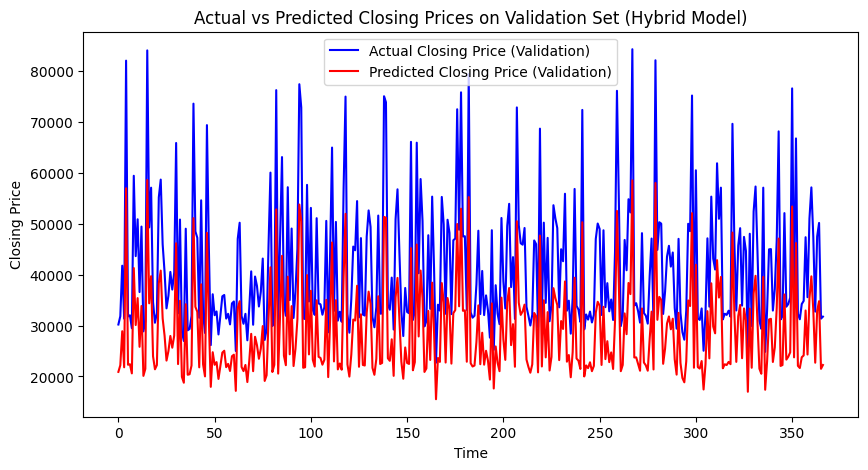

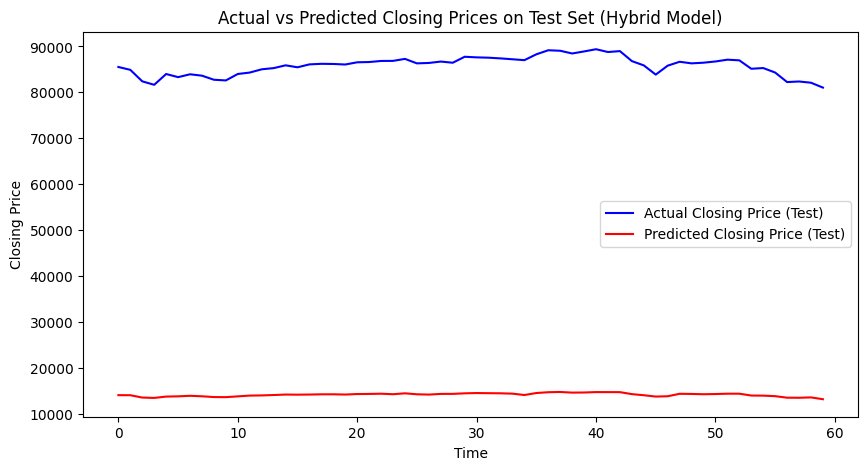

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Step 1: Correct the FFT_for_Period function
class TimesBlock(nn.Module):
    def __init__(self, configs):
        super(TimesBlock, self).__init__()
        self.seq_len = configs.seq_len
        self.pred_len = configs.pred_len
        self.k = configs.top_k
        self.conv = nn.Sequential(
            nn.Conv1d(in_channels=configs.d_model, out_channels=configs.d_ff, kernel_size=3, padding=1),
            nn.GELU(),
        )

    def forward(self, x):
        return self.conv(x)

def FFT_for_Period(x, k):
    xf = torch.fft.rfft(x, dim=1)
    frequency_list = abs(xf).mean(0).mean(-1)
    frequency_list[0] = 0
    k = min(k, frequency_list.size(0))  # Ensure k is within range
    _, top_list = torch.topk(frequency_list, k)
    top_list = top_list.detach().cpu().numpy()
    period = x.shape[1] // top_list
    return period

# Step 2: TimesNet feature extraction module
class TimesNetWrapper(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(TimesNetWrapper, self).__init__()
        configs = type('', (), {})()  # Empty object for configs
        configs.seq_len = 96
        configs.pred_len = 24
        configs.top_k = 3
        configs.d_model = input_dim
        configs.d_ff = 256
        self.timesnet = TimesBlock(configs)
        self.linear = nn.Linear(configs.d_ff * configs.seq_len, output_dim)  # Fixed input_dim for linear layer

    def forward(self, x):
        x = self.timesnet(x)  # Shape: (batch_size, 256, 96)
        x = x.view(x.size(0), -1)  # Flatten before passing to Linear layer
        x = self.linear(x)
        return x


def extract_features_with_timesnet(data, seq_len=96):
    data_reshaped = np.expand_dims(data, axis=1).repeat(seq_len, axis=1)

    model = TimesNetWrapper(input_dim=3, output_dim=3)
    model.eval()
    with torch.no_grad():
        data_tensor = torch.tensor(data_reshaped, dtype=torch.float32).transpose(1, 2)
        features = model(data_tensor)
    return features.numpy()



# Step 3: Load and preprocess data
train_data = pd.read_csv("Training.csv")
test_data = pd.read_csv("Testing.csv")

for col in ["Close", "Open", "High", "Low"]:
    train_data[col] = pd.to_numeric(train_data[col], errors="coerce")
    test_data[col] = pd.to_numeric(test_data[col], errors="coerce")

train_data.dropna(inplace=True)
test_data.dropna(inplace=True)

X_train_full = train_data[["Open", "High", "Low"]].values
y_train_full = train_data["Close"].values
X_test = test_data[["Open", "High", "Low"]].values
y_test = test_data["Close"].values

X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)

# Step 4: Extract TimesNet features
X_train_timesnet = extract_features_with_timesnet(X_train)
X_val_timesnet = extract_features_with_timesnet(X_val)
X_test_timesnet = extract_features_with_timesnet(X_test)

# Reshape for Bi-LSTM
X_train_timesnet = X_train_timesnet.reshape((X_train_timesnet.shape[0], 1, X_train_timesnet.shape[1]))
X_val_timesnet = X_val_timesnet.reshape((X_val_timesnet.shape[0], 1, X_val_timesnet.shape[1]))
X_test_timesnet = X_test_timesnet.reshape((X_test_timesnet.shape[0], 1, X_test_timesnet.shape[1]))

# Step 5: Hybrid Model (TimesNet + Bi-LSTM)
model = Sequential([
    Bidirectional(LSTM(64, activation="relu", return_sequences=True), input_shape=(X_train_timesnet.shape[1], X_train_timesnet.shape[2])),
    Dropout(0.3),
    Bidirectional(LSTM(32, activation="relu")),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse")

# Step 6: Model Training
history = model.fit(X_train_timesnet, y_train, validation_data=(X_val_timesnet, y_val), epochs=40, batch_size=32, verbose=1)

# Step 7: Predictions and Visualization
pred_val = model.predict(X_val_timesnet)
pred_test = model.predict(X_test_timesnet)

plt.figure(figsize=(10, 5))
plt.plot(y_val, label="Actual Closing Price (Validation)", color="blue")
plt.plot(pred_val, label="Predicted Closing Price (Validation)", color="red")
plt.legend()
plt.title("Actual vs Predicted Closing Prices on Validation Set (Hybrid Model)")
plt.xlabel("Time")
plt.ylabel("Closing Price")
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(y_test, label="Actual Closing Price (Test)", color="blue")
plt.plot(pred_test, label="Predicted Closing Price (Test)", color="red")
plt.legend()
plt.title("Actual vs Predicted Closing Prices on Test Set (Hybrid Model)")
plt.xlabel("Time")
plt.ylabel("Closing Price")
plt.show()


In [ ]:
# Predictions
pred_val = model.predict(X_val_timesnet)
pred_test = model.predict(X_test_timesnet)

# Regression Metrics
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    return mae, mse, rmse, mape

print("Validation Metrics:", evaluate(y_val, pred_val))
print("Test Metrics:", evaluate(y_test, pred_test))

# Classification Metrics
def binary_classification_metrics(y_true, y_pred):
    true_binary = np.where(np.diff(y_true, prepend=y_true[0]) > 0, 1, 0)
    pred_binary = np.where(np.diff(y_pred.flatten(), prepend=y_pred[0]) > 0, 1, 0)

    accuracy = accuracy_score(true_binary, pred_binary)
    precision = precision_score(true_binary, pred_binary, zero_division=0)
    recall = recall_score(true_binary, pred_binary, zero_division=0)
    f1 = f1_score(true_binary, pred_binary, zero_division=0)
    auc_roc = roc_auc_score(true_binary, y_pred.flatten())

    return accuracy, precision, recall, f1, auc_roc

print("Validation Classification Metrics:", binary_classification_metrics(y_val, pred_val))
print("Test Classification Metrics:", binary_classification_metrics(y_test, pred_test))


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
Validation Metrics: (12699.23124680688, 176711371.79485306, 13293.282957751748, 0.30517169873216715)
Test Metrics: (71652.69008658854, 5136931708.912792, 71672.39153895168, 0.834800436434812)
Validation Classification Metrics: (0.9945504087193461, 0.989247311827957, 1.0, 0.9945945945945946, 0.8246020432406747)
Test Classification Metrics: (0.7833333333333333, 0.7666666666666667, 0.7931034482758621, 0.7796610169491526, 0.60734149054505)


**OPTIMIZATION**

In [ ]:
pip install keras-tuner


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 4.5 MB/s eta 0:00:00


Trial 30 Complete [00h 02m 06s]
val_loss: 109021960.0

Best val_loss So Far: 2433282.1666666665
Total elapsed time: 01h 10m 01s


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 3630570496.0000
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 687ms/step


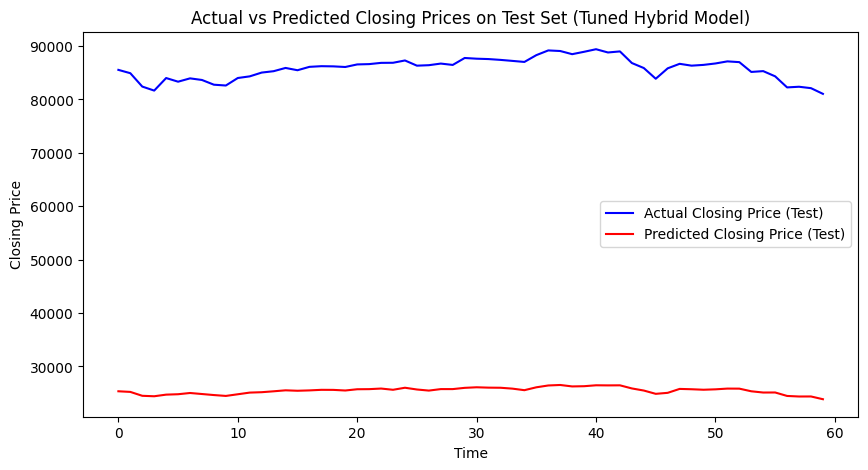

In [ ]:
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Step 1: Define Model with Tunable Hyperparameters
def build_model(hp):
    model = Sequential()
    model.add(Bidirectional(LSTM(
        units=hp.Int('lstm_units_1', min_value=32, max_value=256, step=32),
        activation='relu',
        return_sequences=True
    ), input_shape=(X_train_timesnet.shape[1], X_train_timesnet.shape[2])))

    model.add(Dropout(hp.Float('dropout_1', min_value=0.2, max_value=0.5, step=0.05)))

    model.add(Bidirectional(LSTM(
        units=hp.Int('lstm_units_2', min_value=16, max_value=128, step=16),
        activation='relu'
    )))

    model.add(Dense(1))

    model.compile(
        optimizer=Adam(learning_rate=hp.Float('learning_rate', min_value=1e-5, max_value=1e-2, sampling='log')),
        loss='mse'
    )

    return model

# Step 2: Initialize Bayesian Optimization Tuner
tuner = kt.BayesianOptimization(
    build_model,
    objective='val_loss',
    max_trials=30,
    executions_per_trial=3,
    directory='bayesian_tuning',
    project_name='timesnet_bilstm_tuning_v3'
)

# Step 3: Callback for Early Stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Step 4: Perform Tuning
tuner.search(X_train_timesnet, y_train,
             validation_data=(X_val_timesnet, y_val),
             epochs=60,
             batch_size=32,
             callbacks=[early_stopping])

# Step 5: Retrieve the Best Model
best_model = tuner.get_best_models(num_models=1)[0]

# Step 6: Evaluate the Tuned Model
best_model.evaluate(X_test_timesnet, y_test)

# Step 7: Predictions and Visualization
pred_test = best_model.predict(X_test_timesnet)

plt.figure(figsize=(10, 5))
plt.plot(y_test, label="Actual Closing Price (Test)", color="blue")
plt.plot(pred_test, label="Predicted Closing Price (Test)", color="red")
plt.legend()
plt.title("Actual vs Predicted Closing Prices on Test Set (Tuned Hybrid Model)")
plt.xlabel("Time")
plt.ylabel("Closing Price")
plt.show()


Reloading Tuner from bayesian_tuning/timesnet_bilstm_tuning_v3/tuner0.json


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 3630570496.0000
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 712ms/step


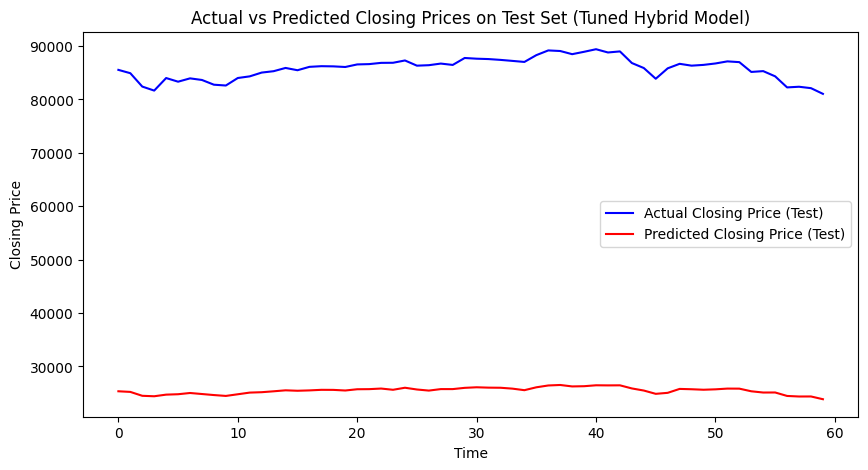

In [ ]:
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Step 1: Define Model with Tunable Hyperparameters
def build_model(hp):
    model = Sequential()
    model.add(Bidirectional(LSTM(
        units=hp.Int('lstm_units_1', min_value=32, max_value=256, step=32),
        activation='relu',
        return_sequences=True
    ), input_shape=(X_train_timesnet.shape[1], X_train_timesnet.shape[2])))

    model.add(Dropout(hp.Float('dropout_1', min_value=0.2, max_value=0.5, step=0.05)))

    model.add(Bidirectional(LSTM(
        units=hp.Int('lstm_units_2', min_value=16, max_value=128, step=16),
        activation='relu'
    )))

    model.add(Dense(1))

    model.compile(
        optimizer=Adam(learning_rate=hp.Float('learning_rate', min_value=1e-5, max_value=1e-2, sampling='log')),
        loss='mse'
    )

    return model

# Step 2: Initialize Bayesian Optimization Tuner
tuner = kt.BayesianOptimization(
    build_model,
    objective='val_loss',
    max_trials=30,
    executions_per_trial=3,
    directory='bayesian_tuning',
    project_name='timesnet_bilstm_tuning_v3'
)

# Step 3: Callback for Early Stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Step 4: Perform Tuning
tuner.search(X_train_timesnet, y_train,
             validation_data=(X_val_timesnet, y_val),
             epochs=60,
             batch_size=32,
             callbacks=[early_stopping])

# Step 5: Retrieve the Best Model
best_model = tuner.get_best_models(num_models=1)[0]

# Step 6: Evaluate the Tuned Model
best_model.evaluate(X_test_timesnet, y_test)

# Step 7: Predictions and Visualization
pred_test = best_model.predict(X_test_timesnet)

plt.figure(figsize=(10, 5))
plt.plot(y_test, label="Actual Closing Price (Test)", color="blue")
plt.plot(pred_test, label="Predicted Closing Price (Test)", color="red")
plt.legend()
plt.title("Actual vs Predicted Closing Prices on Test Set (Tuned Hybrid Model)")
plt.xlabel("Time")
plt.ylabel("Closing Price")
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Step 6.1: Calculate Test Metrics
mse = mean_squared_error(y_test, pred_test)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, pred_test)
r2 = r2_score(y_test, pred_test)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared (R²): {r2:.4f}")

def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape = mean_absolute_percentage_error(y_test, pred_test)
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

# Step 6: Evaluate the Tuned Model
best_model.evaluate(X_test_timesnet, y_test)

# Step 6.1: Compute Metrics
mse = mean_squared_error(y_test, pred_test)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, pred_test)
r2 = r2_score(y_test, pred_test)
mape = mean_absolute_percentage_error(y_test, pred_test)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared (R²): {r2:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")


Mean Squared Error (MSE): 3644292459.2086
Root Mean Squared Error (RMSE): 60367.9754
Mean Absolute Error (MAE): 60350.9603
R-squared (R²): -880.7173
Mean Absolute Percentage Error (MAPE): 70.30%
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 3630570496.0000
Mean Squared Error (MSE): 3644292459.2086
Root Mean Squared Error (RMSE): 60367.9754
Mean Absolute Error (MAE): 60350.9603
R-squared (R²): -880.7173
Mean Absolute Percentage Error (MAPE): 70.30%
